### External noise
Edit the numbers marked `👈` and re-run.

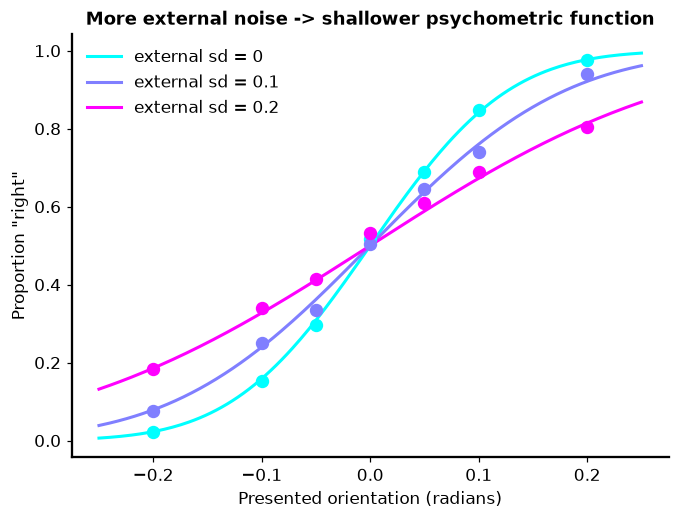

In [1]:
# (hide matplotlib's harmless one-time "building the font cache" message)
import logging; logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "semibold", "axes.linewidth": 1.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": False, "legend.frameon": False,
})

# External noise adds to internal noise, flattening the psychometric function.
signal_strengths = np.array([-0.2,-0.1,-0.05,0,0.05,0.1,0.2])
criterion = 0
noise_sd  = 0.1                      # internal noise
ext_noise_sds = [0, 0.1, 0.2]        # 👈 levels of external noise
ntrials = 1000
rng = np.random.default_rng()

colours = plt.cm.cool(np.linspace(0, 1, len(ext_noise_sds)))
xs = np.linspace(-0.25, 0.25, 200)
fig, ax = plt.subplots(figsize=(7, 5))
for ni, ext in enumerate(ext_noise_sds):
    total = np.sqrt(noise_sd**2 + ext**2)            # variances add
    samples = rng.standard_normal((ntrials, signal_strengths.size)) * total + signal_strengths
    pr = (samples > criterion).mean(axis=0)
    ax.scatter(signal_strengths, pr, 60, color=colours[ni], zorder=3)
    ax.plot(xs, norm.cdf(xs, criterion, total), color=colours[ni], lw=2,
            label=f"external sd = {ext}")
ax.set(xlabel="Presented orientation (radians)", ylabel='Proportion "right"',
       title="More external noise -> shallower psychometric function")
ax.legend()
plt.show()
